# 07 - Post-Training Analysis

This notebook is for **analysis and visualization only** — no training happens here.

All training and evaluation should be run as standalone scripts in the terminal:
```bash
# 1. Generate data
python experiments/gendata_plummer.py --total-n 524288 --test-frac 0.1 \
    --train-out data/plummer_train.h5 --test-out data/plummer_test.h5

# 2. Train DF
python experiments/train_df.py --config configs/df_plummer_ffjord.yaml \
    --data data/plummer_train.h5 --run-dir runs/plummer/df_full \
    --logger wandb+tb

# 3. Evaluate DF
python experiments/eval_df.py --data data/plummer_train.h5 \
    --df-run-dir runs/plummer/df_full --plummer-diag

# 4. Train Phi
python experiments/train_phi.py --config configs/phi_plummer.yaml \
    --data data/plummer_train.h5 --df-run-dir runs/plummer/df_full \
    --run-dir runs/plummer/phi_full --logger wandb+tb

# 5. Evaluate Phi
python experiments/eval_phi.py --data data/plummer_test.h5 \
    --df-run-dir runs/plummer/df_full --phi-run-dir runs/plummer/phi_full
```

Use `--override '{...}'` to pass preset overrides as JSON.

Use `nohup` or `tmux` for long-running training so it survives SSH disconnects.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage

# ─── Configure run directories here ───
PROJECT_ROOT = Path("/localdisk/kosmos/my-deep-potential")
RUNS_DIR = PROJECT_ROOT / "runs"

DF_RUN = RUNS_DIR / "plummer" / "df_full_ffjord"   # or df_full, df_smoke, etc.
PHI_RUN = RUNS_DIR / "plummer" / "phi_full_v2"

# For multi-run comparison, add more dirs:
# DF_RUN_2 = RUNS_DIR / "plummer" / "df_fast"
# PHI_RUN_2 = RUNS_DIR / "plummer" / "phi_fast"

print(f"DF_RUN:  {DF_RUN}  (exists: {DF_RUN.exists()})")
print(f"PHI_RUN: {PHI_RUN} (exists: {PHI_RUN.exists()})")

DF_RUN:  /localdisk/kosmos/my-deep-potential/runs/plummer/df_full_ffjord  (exists: True)
PHI_RUN: /localdisk/kosmos/my-deep-potential/runs/plummer/phi_full_v2 (exists: True)


## DF Training Curves

Reads `metrics.csv` from the DF run directory and plots loss + score statistics.

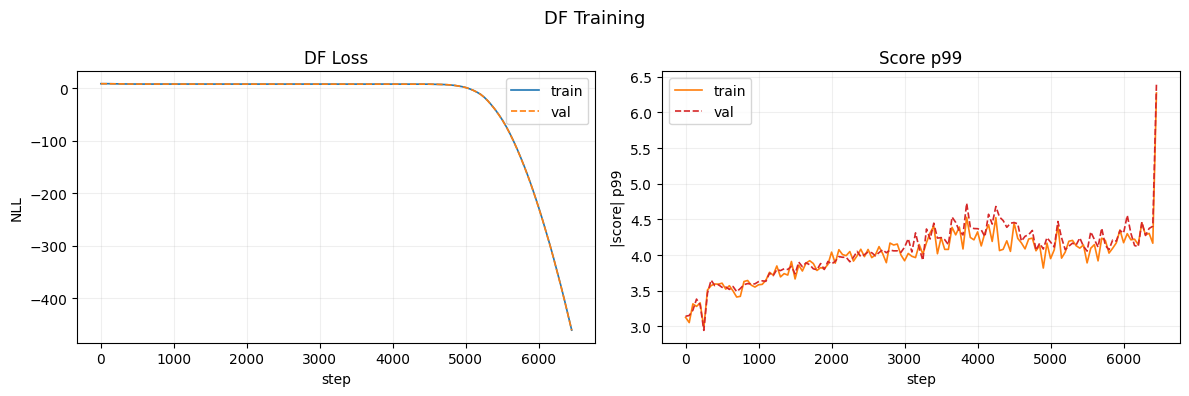

In [5]:
import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dpjax.plotting.training_curves import plot_df_training

if (DF_RUN / "metrics.csv").exists():
    plot_df_training(DF_RUN)
    plt.show()
else:
    print(f"No metrics.csv found at {DF_RUN}")

## DF Diagnostics

Display pre-generated diagnostic plots from `{DF_RUN}/plots/`.
These are created by `python experiments/eval_df.py --plummer-diag`.

In [7]:
df_plots = DF_RUN / "plots"

diag_files = [
    "flow_gradients_comparison.png",
    "flow_gradients_comparison_hist.png",
    "df_rv_comparison.png",
    "marginals_grid.png",
]

for fname in diag_files:
    p = df_plots / fname
    if p.exists():
        print(f"\n--- {fname} ---")
        display(IPImage(filename=str(p)))
    else:
        print(f"  [skip] {fname} not found")

  [skip] flow_gradients_comparison.png not found
  [skip] flow_gradients_comparison_hist.png not found
  [skip] df_rv_comparison.png not found
  [skip] marginals_grid.png not found


## Phi Training Curves

Reads `metrics.csv` from the Phi run directory and plots loss + residual statistics.

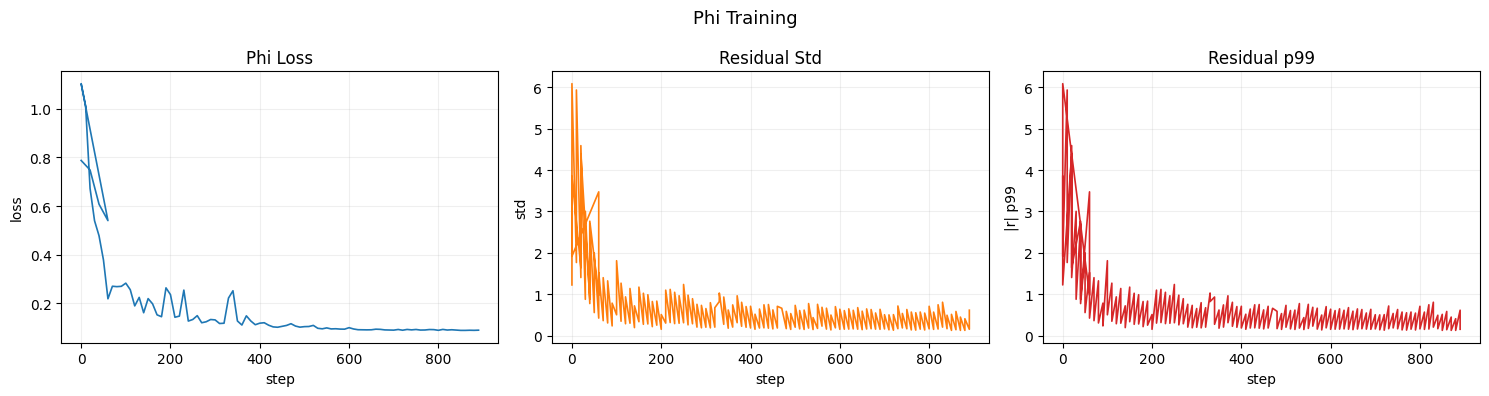

In [8]:
from dpjax.plotting.training_curves import plot_phi_training

if (PHI_RUN / "metrics.csv").exists():
    plot_phi_training(PHI_RUN)
    plt.show()
else:
    print(f"No metrics.csv found at {PHI_RUN}")

## Phi Evaluation: Radial Curves

Load `radial_curves_plummer.npz` saved by `eval_phi.py` and plot potential + acceleration.

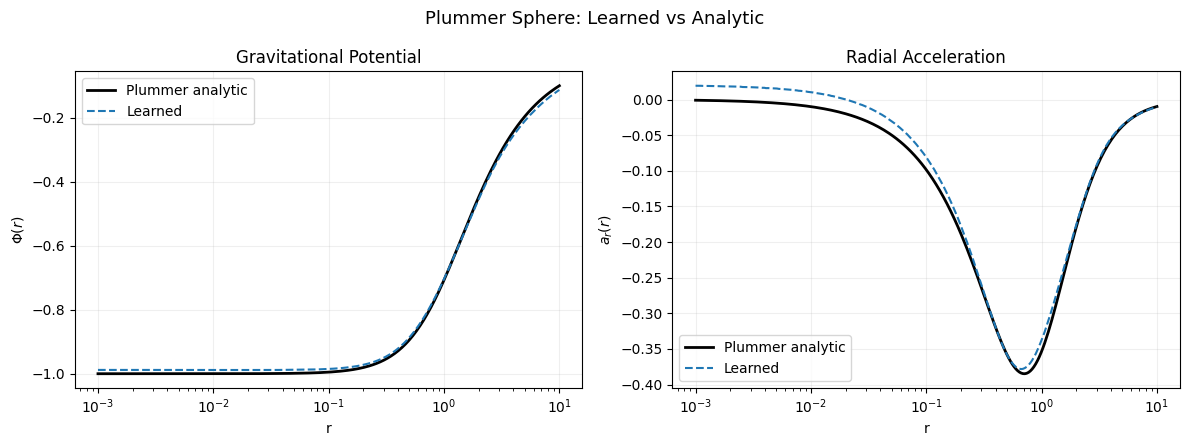

In [9]:
phi_eval_dir = PHI_RUN  # eval_phi saves eval_stats.json and radial_curves_plummer.npz here
phi_plots_dir = PHI_RUN / "plots"  # eval_phi saves plots here
npz_path = phi_eval_dir / "radial_curves_plummer.npz"

if npz_path.exists():
    rad = dict(np.load(npz_path))
    r = rad["r"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    ax1.plot(r, rad["phi_true"], "k-", lw=2, label="Plummer analytic")
    ax1.plot(r, rad["phi_learned_shift"], "--", lw=1.5, label="Learned")
    ax1.set_xscale("log"); ax1.set_xlabel("r"); ax1.set_ylabel(r"$\Phi(r)$")
    ax1.legend(); ax1.set_title("Gravitational Potential")
    ax1.grid(True, alpha=0.2)

    ax2.plot(r, rad["ar_true"], "k-", lw=2, label="Plummer analytic")
    ax2.plot(r, rad["ar_learned"], "--", lw=1.5, label="Learned")
    ax2.set_xscale("log"); ax2.set_xlabel("r"); ax2.set_ylabel(r"$a_r(r)$")
    ax2.legend(); ax2.set_title("Radial Acceleration")
    ax2.grid(True, alpha=0.2)

    fig.suptitle("Plummer Sphere: Learned vs Analytic", fontsize=13)
    fig.tight_layout()
    plt.show()
else:
    # Fall back to pre-rendered images
    for img_name in ["phi_r_plummer.png", "ar_r_plummer.png"]:
        p = phi_plots_dir / img_name
        if p.exists():
            display(IPImage(filename=str(p)))
        else:
            print(f"  [skip] {img_name} not found")

## Residual Statistics

Load `eval_stats.json` from Phi evaluation.

In [10]:
import json

stats_path = phi_eval_dir / "eval_stats.json"
if stats_path.exists():
    stats = json.loads(stats_path.read_text())
    print("Phi evaluation residual statistics:")
    for k, v in stats.items():
        print(f"  {k}: {v}")
else:
    print(f"No eval_stats.json found at {phi_eval_dir}")
    print("Run: python experiments/eval_phi.py --data ... --df-run-dir ... --phi-run-dir ...")

Phi evaluation residual statistics:
  n_eval: 32768
  residual_mean: 0.00043269613524898887
  residual_std: 0.19442206621170044
  residual_p99_abs: 0.6211254596710205
  residual_p999_abs: 1.566629409790039
  residual_max_abs: 18.865089416503906


## Multi-Run Comparison (Optional)

Compare training curves from multiple experiments side by side.

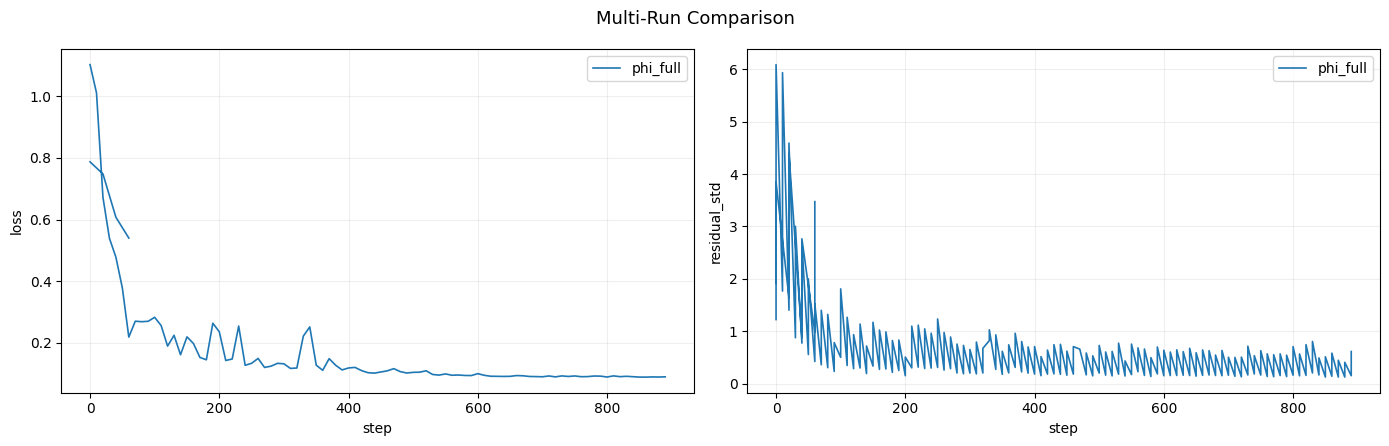

In [11]:
import csv

def _read_metrics(run_dir: Path) -> dict:
    """Read metrics.csv into a dict of numpy arrays."""
    p = run_dir / "metrics.csv"
    if not p.exists():
        return {}
    with p.open("r", newline="") as f:
        reader = csv.DictReader(f)
        cols = {k: [] for k in (reader.fieldnames or [])}
        for row in reader:
            for k in cols:
                try:
                    cols[k].append(float(row.get(k, "nan")))
                except ValueError:
                    cols[k].append(float("nan"))
    return {k: np.array(v) for k, v in cols.items()}


# Example: compare two Phi runs
runs_to_compare = {
    "phi_full": PHI_RUN,
    # "phi_fast": RUNS_DIR / "plummer" / "phi_fast",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for label, rdir in runs_to_compare.items():
    m = _read_metrics(rdir)
    if not m:
        print(f"  [skip] {label}: no metrics.csv")
        continue
    step = m.get("step", np.arange(len(next(iter(m.values())))))
    if "loss" in m:
        axes[0].plot(step, m["loss"], label=label, lw=1.2)
    if "residual_std" in m:
        axes[1].plot(step, m["residual_std"], label=label, lw=1.2)

axes[0].set_xlabel("step"); axes[0].set_ylabel("loss"); axes[0].legend(); axes[0].grid(True, alpha=0.2)
axes[1].set_xlabel("step"); axes[1].set_ylabel("residual_std"); axes[1].legend(); axes[1].grid(True, alpha=0.2)
fig.suptitle("Multi-Run Comparison", fontsize=13)
fig.tight_layout()
plt.show()

---

# Extended Diagnostics

The following sections load pre-computed `.npz` data from `eval_df.py` / `eval_phi.py` and display diagnostic plots.
No GPU or model loading required.

**Prerequisite**: Run the eval scripts first:
```bash
python experiments/eval_df.py --data data/plummer_train.h5 \
    --df-run-dir runs/plummer/df_full_ffjord --plummer-diag

python experiments/eval_phi.py --data data/plummer_test.h5 \
    --df-run-dir runs/plummer/df_full_ffjord --phi-run-dir runs/plummer/phi_full_v2
```

In [ ]:
from dpjax.plotting.diagnostics import (
    plot_phase_space_grid,
    plot_score_comparison,
    plot_score_residual_hist,
    plot_rv_comparison,
    plot_phi_rho_slice,
    plot_density_profile,
    plot_residual_spatial,
)

# Derived paths for saved evaluation data
DF_PLOTS = DF_RUN / "plots"
PHI_PLOTS = PHI_RUN / "plots"

## 1. DF Phase-Space Overview

3×3 grid: spatial projections, velocity projections, r-v diagram, and isotropy checks.
Red contours show flow samples overlaid on training data.

In [ ]:
samples_path = DF_PLOTS / "df_samples.npz"
if samples_path.exists():
    d = dict(np.load(samples_path))
    fig = plot_phase_space_grid(d["eta_train"], eta_sample=d["eta_sample"])
    plt.show()
else:
    print(f"[skip] {samples_path} not found — run eval_df.py first")

## 2. Score Gradient Comparison

Scatter plot of true (analytic Plummer) vs learned (FFJORD) score ∂log f/∂η per dimension.
Slope ≈ 1 and R² ≈ 1 indicates good flow quality.

In [ ]:
grad_path = DF_PLOTS / "gradient_comparison.npz"
if grad_path.exists():
    g = dict(np.load(grad_path))
    fig = plot_score_comparison(g["score_true"], g["score_est"])
    plt.show()
else:
    print(f"[skip] {grad_path} not found — run eval_df.py --plummer-diag first")

## 3. Score Gradient Residual Histograms

Distribution of (learned − true) score per dimension. σ = residual std, κ = excess kurtosis.

In [ ]:
if grad_path.exists():
    g = dict(np.load(grad_path))
    fig = plot_score_residual_hist(g["score_true"], g["score_est"])
    plt.show()
else:
    print(f"[skip] {grad_path} not found")

## 4. r-v Distribution Comparison

3×2 grid comparing ideal Plummer DF vs flow samples in (r, v) space.
Rows: ideal, flow, residuals. Columns: linear, log scale. Red line = zero-energy boundary.

In [ ]:
rv_path = DF_PLOTS / "rv_comparison.npz"
if rv_path.exists():
    rv = dict(np.load(rv_path))
    fig = plot_rv_comparison(
        rv["n_ideal"], rv["n_samp"], rv["r"], rv["v"],
        n_flow_total=int(rv["n_flow_total"]),
    )
    plt.show()
else:
    print(f"[skip] {rv_path} not found — run eval_df.py --plummer-diag first")

## 5. Φ / ρ / |a| 2D Slices

Cross-section at z=0 of the learned potential, inferred density, and acceleration magnitude.
Generated by `experiments/plot_phi_slice.py`.

In [ ]:
slice_path = PHI_PLOTS / "phi_slice_xy.npz"
if slice_path.exists():
    sl = dict(np.load(slice_path))
    fig = plot_phi_rho_slice(sl["x"], sl["y"], sl["phi"], sl["rho"], sl["acc_mag"])
    plt.show()
else:
    print(f"[skip] {slice_path} not found")
    print("Run: python experiments/plot_phi_slice.py --df-run-dir ... --phi-run-dir ...")

## 6. Radial Density Profile ρ(r)

Learned ρ(r) = ∇²Φ / (4π) vs analytic Plummer density, along with Φ(r) and a_r(r).

In [ ]:
npz_path = PHI_RUN / "radial_curves_plummer.npz"
if npz_path.exists():
    rad = dict(np.load(npz_path))
    r = rad["r"]
    kwargs = dict(r=r, rho_learned=rad["rho_learned"], rho_analytic=rad["rho_analytic"])
    if "phi_learned_shift" in rad:
        kwargs.update(phi_learned_shift=rad["phi_learned_shift"], phi_true=rad["phi_true"])
    if "ar_learned" in rad:
        kwargs.update(ar_learned=rad["ar_learned"], ar_true=rad["ar_true"])
    fig = plot_density_profile(**kwargs)
    plt.show()
else:
    print(f"[skip] {npz_path} not found — run eval_phi.py first")

## 7. CBE Residual Spatial Map

Hexbin map of median |residual| in (x,y) and (x,z) projections.
Shows where the Collisionless Boltzmann Equation is least well satisfied.

In [ ]:
resid_path = PHI_RUN / "residual_spatial.npz"
if resid_path.exists():
    rs = dict(np.load(resid_path))
    fig = plot_residual_spatial(rs["x"], rs["y"], rs["z"], rs["residual"])
    plt.show()
else:
    print(f"[skip] {resid_path} not found — run eval_phi.py first")